### About EDA

This notebook explores the **raw** Rossmann data before cleaning. It informs the feature-engineering decisions applied in Cleaning.ipynb.

`Run order:` EDA.ipynb -> Cleaning.ipynb -> Modeling.ipynb.

---

### About the dataset

This dataset shows Rossmann's store sales, which are influenced by many factors, like promotions, competition, school and state holidays, seasonality and location.

In this project I have to predict 6 weeks of daily sales for 1,115 stores located across Germany. And by building reliable forecasting model I will enable Rossmann's managers to organize staff schedules, delivery and promotion planning more effectively, which will increase productivity and sales.

Without model finding patterns and make decisions for efficient store management will be extremely hard because of the amount of factors which human can't consider.


Dataset by itself divided into 4 parts. In this notebook I'll work with train and store parts which contains train data and other useful features for model training.


### Import

In [70]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [71]:
from src.data import load_raw_data

df = load_raw_data("../data/raw")

print(df.shape)
print(df.dtypes)

(1017209, 18)
Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object


### Correlation

In [72]:
num_cols = df.select_dtypes(include="number").columns
print(list(num_cols))

['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear']


In [73]:
corr_with_target = df[num_cols].corr(method="spearman")["Sales"].drop("Sales")

I used spearman method because I wanna know does each feature tend to decrease or increase with Sales instead of linear correlation.

---

In [74]:
top_positive = corr_with_target.sort_values(ascending=False).head(10)
top_negative = corr_with_target.sort_values().head(10)

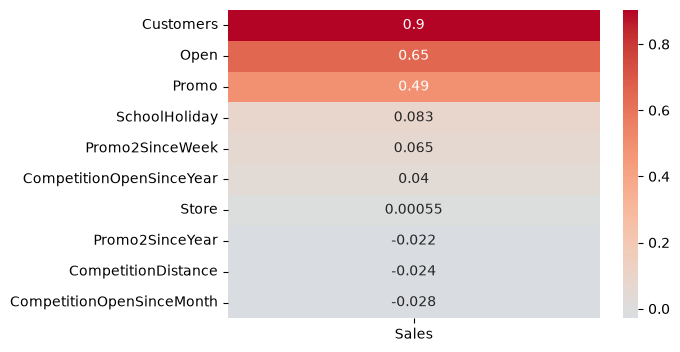

In [75]:
heatmap_data_pos = top_positive.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_pos, annot=True, center=0, cmap="coolwarm")

plt.show()

Based on top positive correlation heatmap I found out that Sales tend to increase if:
- There are many customers (Spearman corr ~0.90) - but Customers is a same-day count that is essentially the target itself, so it is dropped in Cleaning as target leakage.

- Store is open (corr ~0.65) - but Open == 0 implies Sales == 0 deterministically, so it is handled by the two-stage split in Modeling, not as a regressor feature.

And that is pretty obvious but there are also 3 insightful examples. Sales will increase if:
- Store is on Promo (corr ~0.49), which shows that promo works

- If there is a school holiday (corr ~0.08) - students tend to go to store

- And if store type is B (there is no certain information about its exact meaning)


---

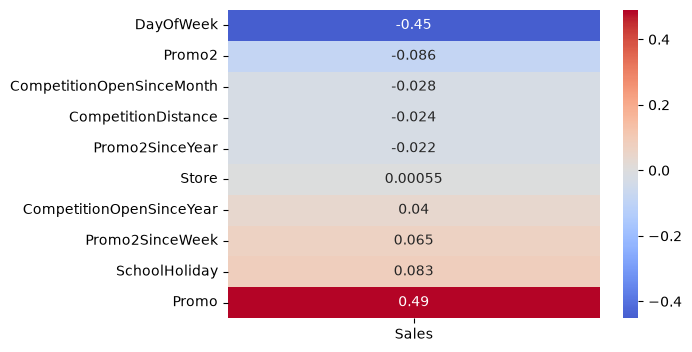

In [76]:
heatmap_data_neg = top_negative.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_neg, annot=True, center=0, cmap="coolwarm")

plt.show()

Based on top negative correlation heatmap I found out that Sales tend to decrease if:
- It is Sunday (DayOfWeek corr ~-0.45) which is easily explained by EU system -> Stores are closed on Sundays (only 2.5% of Sundays are open).

- If store is participating in a Second promotion (Promo2 corr ~-0.09) - stores running Promo2 tend to have lower baseline sales.

- If there is more competition nearby (CompetitionDistance corr ~-0.02) - closer competitors slightly reduce sales.


---

### Outliers

In [77]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Sales"] < Q1 - 1.5 * IQR) | (df["Sales"] > Q3 + 1.5 * IQR)]

In [78]:
print(f"Outliers: {len(outliers):,}")
print(f"Percentage: {len(outliers) / len(df) * 100:.2f}%")

Outliers: 26,694
Percentage: 2.62%


In [79]:
outliers[["Store", "Sales", "Promo", "SchoolHoliday", "DayOfWeek"]].sort_values(
    "Sales", ascending=False
).head(20)

,Store,Sales,Promo,SchoolHoliday,DayOfWeek
44393,909,41551,0,0,1
132946,262,38722,1,0,5
101726,262,38484,1,0,5
87231,262,38367,0,1,4
424086,57,38037,1,0,1
627776,817,38025,1,0,1
627220,261,37646,1,0,1
444361,262,37403,0,0,4
620531,262,37376,0,0,7
245945,262,37122,0,0,7


In some outliers cases i noticed that there are:
- too few customers for such a big sales

- or there are just too many of customers

Threshold is above 4900 and under 1900 customers.


In [80]:
df["is_outlier"] = df["Sales"].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR).eq(False)

df.groupby("is_outlier")[["Sales", "Customers", "Promo"]].agg(["mean", "median"])

Sales             Customers             Promo       
                    mean   median         mean  median      mean median
is_outlier                                                             
False        5465.548842   5651.0   596.658678   600.0  0.372425    0.0
True        17212.576309  16288.0  1987.052708  1834.0  0.718776    1.0

In [81]:
df["SalesPerCustomer"] = df["Sales"] / df["Customers"].replace(0, np.nan)

df["SalesPerCustomer"].describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalesPerCustomer, dtype: float64

In [82]:
df.nlargest(20, "SalesPerCustomer")[
    ["Store", "Sales", "Customers", "SalesPerCustomer", "Promo", "StateHoliday"]
]

,Store,Sales,Customers,SalesPerCustomer,Promo,StateHoliday
744931,897,16954,261,64.957854,0,0
686180,126,33071,574,57.614983,1,0
688410,126,30619,554,55.268953,1,0
875386,897,17148,319,53.755486,0,0
697330,126,25049,475,52.734737,0,0
728206,897,11166,216,51.694444,0,0
692526,897,16558,331,50.024169,0,0
889881,897,11805,244,48.381148,1,0
763886,897,17649,386,45.722798,1,0
673571,897,15991,353,45.300283,1,0


In top 20 outliers sales per customer are 6 times higher than in regular values and there is no holiday.


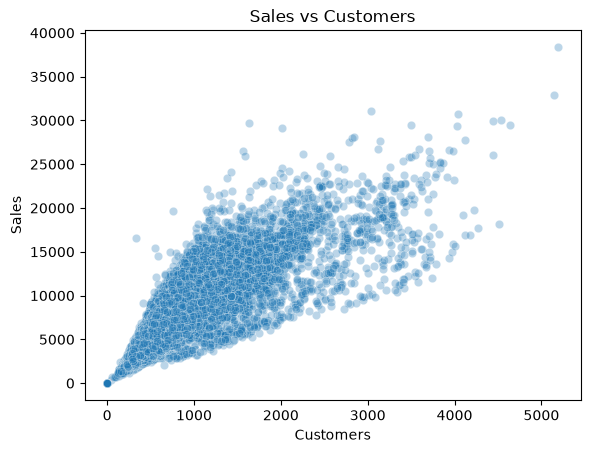

In [83]:
sns.scatterplot(
    data=df.sample(50_000, random_state=42), x="Customers", y="Sales", alpha=0.3
)

plt.title("Sales vs Customers")
plt.show()

Sales contains substantial extreme values, but these observations should not automatically be removed because high sales can correspond to legitimate differences in store traffic, promotions, and temporal effects.

---

### Other data manipulation

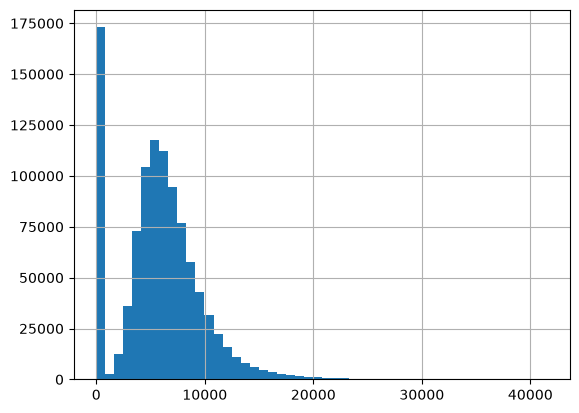

In [84]:
df["Sales"].hist(bins=50)
plt.show()

As expected Sales is `right-skewed distributed` -> there are cases when store made 8 times more than usual.

In [85]:
# Raw Date is a string - parse it for time-based analysis
df["Date"] = pd.to_datetime(df["Date"])
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month

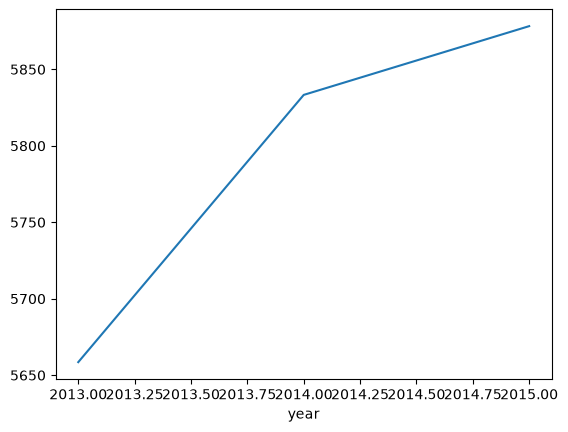

In [86]:
df.groupby("year")["Sales"].mean().plot()
plt.show()

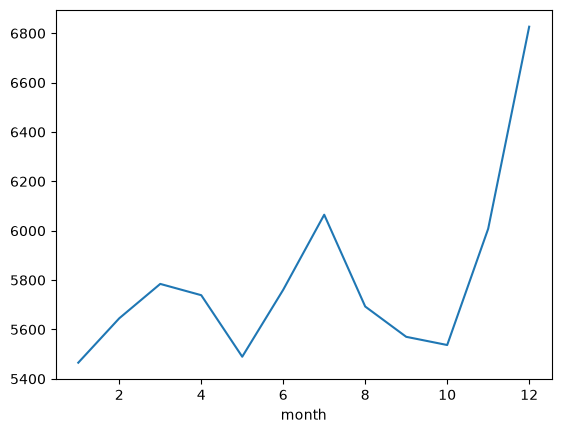

In [87]:
df.groupby("month")["Sales"].mean().plot()
plt.show()

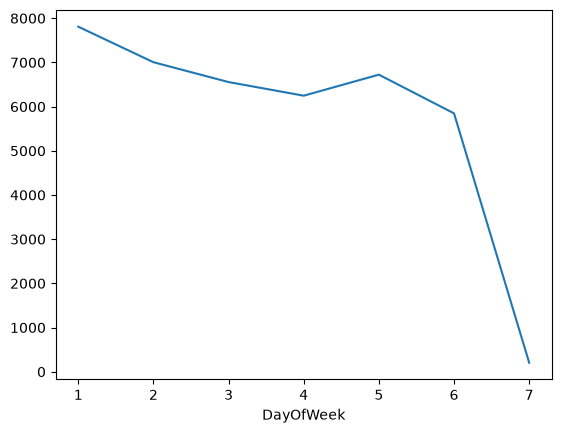

In [88]:
df.groupby("DayOfWeek")["Sales"].mean().plot()
plt.show()

Based on those plots i can tell that:
- Sales grew up for 4% from 2013 to 2015.

- The spike of sales can be expected during June-July and October-December periods.

- Mondays have the highest average sales (~7800), and Sundays are nearly zero (~204) because stores are closed.

Note: the Sunday average is dragged down by closed stores (Sales == 0). The Cleaning step handles closed stores via the two-stage split.


---

### Hand-off to Cleaning

This EDA explored the raw data and informed the cleaning decisions:
- **Customers** is target leakage (Spearman corr ~0.90 with Sales) -> dropped in Cleaning.
- **Open** is deterministic (Open == 0 implies Sales == 0) -> kept as a split column, not a feature.
- **Missing values** (CompetitionDistance, Promo2, PromoInterval) -> filled in Cleaning.
- **Sunday closure** (only 2.5% of Sundays open) -> handled by the two-stage split.

---